# 实验二：循环神经网络（RNN）与 LSTM 时间序列预测

对应《深度学习实验任务书2：循环神经网络 RNN 实验》。使用 **Python + PyTorch** 自写数据构造与模型，对 **sin(pi * x)** 在 x 属于 [0, 3) 上的采样序列做归一化，用 **前 3 个时刻** 预测 **下一时刻**（look_back=3），完成简单 RNN、改进的 LSTM/GRU，并完成拓展对比。

说明：任务书使用 Variable，当前 PyTorch 可直接用张量；损失为回归 MSELoss。


## 1. 环境与依赖

在 exp/exp2/ 目录执行：

```bash
pip install -r requirements.txt
```

使用 Jupyter 打开本笔记本，在实验机上依次运行。


In [1]:
import math
import random
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 2. 构造数据集

用 numpy.arange(0, 3, 0.01) 生成横坐标，纵坐标为 sin(x * pi)。归一化采用最小-最大缩放到 [0, 1]。

create_dataset：滑动窗口 look_back=3，预测后 1 个值。


In [2]:
dataset = []
for x in np.arange(0, 3, 0.01, dtype=np.float64):
    dataset.append(math.sin(float(x) * math.pi))
dataset = np.array(dataset, dtype="float32")

max_value = float(np.max(dataset))
min_value = float(np.min(dataset))
scalar = max_value - min_value
if scalar < 1e-12:
    raise ValueError("scalar too small")
dataset_norm = (dataset - min_value) / scalar


def create_dataset(data: np.ndarray, look_back: int = 3) -> Tuple[np.ndarray, np.ndarray]:
    data_x, data_y = [], []
    for i in range(len(data) - look_back):
        data_x.append(data[i : i + look_back])
        data_y.append(data[i + look_back])
    return np.array(data_x, dtype="float32"), np.array(data_y, dtype="float32")


data_X, data_Y = create_dataset(dataset_norm, look_back=3)
print("X shape:", data_X.shape, "Y shape:", data_Y.shape)

train_ratio = 0.67
n_train = int(len(data_X) * train_ratio)
train_X, train_Y = data_X[:n_train], data_Y[:n_train]
test_X, test_Y = data_X[n_train:], data_Y[n_train:]
print("train:", train_X.shape, "test:", test_X.shape)


X shape: (297, 3) Y shape: (297,)
train: (198, 3) test: (99, 3)


## 3. 张量形状（任务书：batch, 1, 3）

每个样本为序列长度 1、特征维 3，与 RNN(3, 20) 的 input_size=3 一致。


In [3]:
def to_tensor_xy(train_X, train_Y, test_X, test_Y):
    train_X = train_X.reshape(-1, 1, 3)
    train_Y = train_Y.reshape(-1, 1, 1)
    test_X = test_X.reshape(-1, 1, 3)
    test_Y = test_Y.reshape(-1, 1, 1)
    train_x = torch.from_numpy(train_X).to(device)
    train_y = torch.from_numpy(train_Y).to(device)
    test_x = torch.from_numpy(test_X).to(device)
    test_y = torch.from_numpy(test_Y).to(device)
    return train_x, train_y, test_x, test_y


train_x, train_y, test_x, test_y = to_tensor_xy(train_X, train_Y, test_X, test_Y)
print(train_x.shape, train_y.shape)


torch.Size([198, 1, 3]) torch.Size([198, 1, 1])


## 4. RNN 模型（含全连接）

参考 PyTorch 文档 torch.nn.RNN，batch_first=True。


In [4]:
class RNNRegressor(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        output_size: int = 1,
        num_layers: int = 2,
        rnn_type: str = "rnn",
    ):
        super().__init__()
        self.rnn_type = rnn_type
        if rnn_type == "rnn":
            self.rnn = nn.RNN(
                input_size, hidden_size, num_layers, batch_first=True, nonlinearity="tanh"
            )
        elif rnn_type == "lstm":
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        elif rnn_type == "gru":
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        else:
            raise ValueError("rnn_type must be rnn, lstm, gru")
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.linear(last)


def train_model(
    model: nn.Module,
    train_x: torch.Tensor,
    train_y: torch.Tensor,
    epochs: int = 1000,
    lr: float = 1e-2,
    log_every: int = 100,
) -> List[float]:
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for e in range(epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        pred = model(train_x)
        loss = criterion(pred, train_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if (e + 1) % log_every == 0:
            print("Epoch {}, Loss: {:.10f}".format(e + 1, loss.item()))
    return losses


@torch.no_grad()
def predict_series(model: nn.Module, test_x: torch.Tensor) -> np.ndarray:
    model.eval()
    return model(test_x).cpu().numpy().flatten()


def denormalize(y_norm: np.ndarray) -> np.ndarray:
    return y_norm * scalar + min_value


def plot_true_pred(y_true_norm: np.ndarray, y_pred_norm: np.ndarray, title: str, n_show: int = 200):
    yt = denormalize(y_true_norm[:n_show])
    yp = denormalize(y_pred_norm[:n_show])
    plt.figure(figsize=(9, 4))
    plt.plot(yt, "b-", label="真实值", linewidth=1.2)
    plt.plot(yp, "r-", label="预测值", linewidth=1.2)
    plt.legend()
    plt.title(title)
    plt.xlabel("测试集时间步")
    plt.ylabel("反归一化幅值")
    plt.tight_layout()
    plt.show()


## 5. 训练简单 RNN（任务书：input 3, hidden 20, num_layers=2）

MSELoss，Adam，lr=1e-2，1000 epoch。


/home/hongchang/miniconda3/envs/dl-exp3/lib/python3.10/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([198, 1, 1])) that is different to the input size (torch.Size([198, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 100, Loss: 0.1262634397
Epoch 200, Loss: 0.1262607276
Epoch 300, Loss: 0.1262602657
Epoch 400, Loss: 0.1262597889
Epoch 500, Loss: 0.1262593418
Epoch 600, Loss: 0.1262588948
Epoch 700, Loss: 0.1262585074
Epoch 800, Loss: 0.1262581348
Epoch 900, Loss: 0.1262578219
Epoch 1000, Loss: 0.1262575388
测试集 MSE（归一化空间）RNN: 0.1267397105693817


/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}

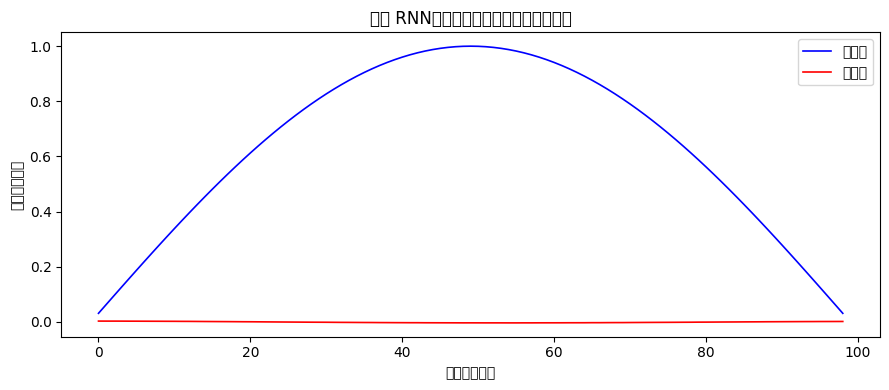

In [5]:
torch.manual_seed(42)
net_rnn = RNNRegressor(input_size=3, hidden_size=20, output_size=1, num_layers=2, rnn_type="rnn")
losses_rnn = train_model(net_rnn, train_x, train_y, epochs=1000, lr=1e-2, log_every=100)

pred_rnn = predict_series(net_rnn, test_x)
mse_test_rnn = float(np.mean((pred_rnn - test_y.cpu().numpy().flatten()) ** 2))
print("测试集 MSE（归一化空间）RNN:", mse_test_rnn)
plot_true_pred(test_y.cpu().numpy().flatten(), pred_rnn, "简单 RNN：真实值（蓝）与预测值（红）")


## 6. LSTM（改进模型）


Epoch 100, Loss: 0.1262567937
Epoch 200, Loss: 0.1262563467
Epoch 300, Loss: 0.1262563467
Epoch 400, Loss: 0.1262563467
Epoch 500, Loss: 0.1262563467
Epoch 600, Loss: 0.1262563467
Epoch 700, Loss: 0.1262563467
Epoch 800, Loss: 0.1262563467
Epoch 900, Loss: 0.1262563467
Epoch 1000, Loss: 0.1262563467
测试集 MSE（归一化空间）LSTM: 0.12640368938446045


/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8390/3927949111.py:75: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}

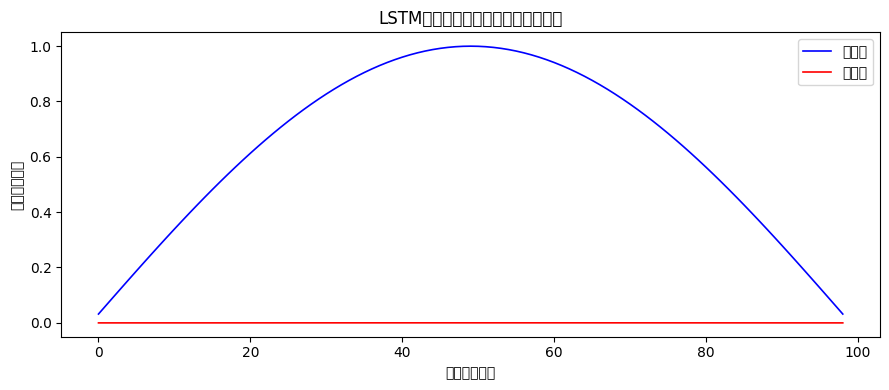

In [6]:
torch.manual_seed(42)
net_lstm = RNNRegressor(input_size=3, hidden_size=20, output_size=1, num_layers=2, rnn_type="lstm")
losses_lstm = train_model(net_lstm, train_x, train_y, epochs=1000, lr=1e-2, log_every=100)

pred_lstm = predict_series(net_lstm, test_x)
mse_test_lstm = float(np.mean((pred_lstm - test_y.cpu().numpy().flatten()) ** 2))
print("测试集 MSE（归一化空间）LSTM:", mse_test_lstm)
plot_true_pred(test_y.cpu().numpy().flatten(), pred_lstm, "LSTM：真实值（蓝）与预测值（红）")


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(losses_rnn, label="RNN train MSE")
plt.plot(losses_lstm, label="LSTM train MSE")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("训练损失曲线")
plt.tight_layout()
plt.show()


## 后续实验（拓展 1）：GRU 与 LSTM 对比


In [ ]:
torch.manual_seed(42)
net_gru = RNNRegressor(input_size=3, hidden_size=20, output_size=1, num_layers=2, rnn_type="gru")
losses_gru = train_model(net_gru, train_x, train_y, epochs=1000, lr=1e-2, log_every=100)

pred_gru = predict_series(net_gru, test_x)
mse_test_gru = float(np.mean((pred_gru - test_y.cpu().numpy().flatten()) ** 2))
print("测试集 MSE GRU:", mse_test_gru)

plot_true_pred(test_y.cpu().numpy().flatten(), pred_gru, "GRU：真实值（蓝）与预测值（红）")

plt.figure(figsize=(9, 4))
n_show = 200
plt.plot(denormalize(test_y.cpu().numpy().flatten()[:n_show]), "b-", label="真实值", alpha=0.8)
plt.plot(denormalize(pred_lstm[:n_show]), "g--", label="LSTM", linewidth=1.2)
plt.plot(denormalize(pred_gru[:n_show]), "m:", label="GRU", linewidth=1.2)
plt.legend()
plt.title("LSTM vs GRU 预测曲线对比（反归一化）")
plt.tight_layout()
plt.show()


## 后续实验（拓展 2）：多层 RNN 层数对比

比较 num_layers=1 与 num_layers=3 的 vanilla RNN 在测试集上的预测曲线。


In [ ]:
results = {}
for nl in (1, 3):
    torch.manual_seed(42)
    m = RNNRegressor(input_size=3, hidden_size=20, output_size=1, num_layers=nl, rnn_type="rnn")
    train_model(m, train_x, train_y, epochs=1000, lr=1e-2, log_every=500)
    pr = predict_series(m, test_x)
    mse = float(np.mean((pr - test_y.cpu().numpy().flatten()) ** 2))
    results["RNN_layers={}".format(nl)] = (pr, mse)
    print("RNN num_layers={} 测试MSE(归一化): {:.8f}".format(nl, mse))

plt.figure(figsize=(9, 4))
n_show = 200
yt = denormalize(test_y.cpu().numpy().flatten()[:n_show])
plt.plot(yt, "b-", label="真实值", linewidth=1.5)
for name, (pr, _) in results.items():
    plt.plot(denormalize(pr[:n_show]), "--", label=name, linewidth=1.1)
plt.legend()
plt.title("多层 RNN：不同层数的预测曲线对比")
plt.tight_layout()
plt.show()


## 保存实验数据与图片

在**完成上述训练单元格**之后运行：将序列、预测、训练损失与图像写入 `experiment_outputs/rnn_sin/`。未运行的拓展（无对应变量）会自动跳过。


In [ ]:
# 在 RNN/LSTM 等训练单元格执行完毕后再运行本格
import json
from datetime import datetime
from pathlib import Path

EXP_DIR = Path("experiment_outputs") / "rnn_sin"
EXP_DIR.mkdir(parents=True, exist_ok=True)

ty = test_y.cpu().numpy().flatten()

series_npz = {
    "dataset_norm": np.asarray(dataset_norm, dtype=np.float64),
    "train_X": np.asarray(train_X, dtype=np.float32),
    "train_Y": np.asarray(train_Y, dtype=np.float32),
    "test_X": np.asarray(test_X, dtype=np.float32),
    "test_Y": np.asarray(test_Y, dtype=np.float32),
    "test_y_norm": ty.astype(np.float64),
}
np.savez_compressed(EXP_DIR / "data_series.npz", **series_npz)

pred_npz = {"test_y_norm": ty.astype(np.float64)}
for key in ("pred_rnn", "pred_lstm", "pred_gru"):
    if key in globals():
        pred_npz[key] = np.asarray(globals()[key], dtype=np.float64)
np.savez_compressed(EXP_DIR / "predictions.npz", **pred_npz)

loss_npz = {}
for key in ("losses_rnn", "losses_lstm", "losses_gru"):
    if key in globals():
        loss_npz[key] = np.asarray(globals()[key], dtype=np.float64)
if loss_npz:
    np.savez_compressed(EXP_DIR / "train_losses.npz", **loss_npz)

if "results" in globals() and results:
    layer_npz = {}
    meta_layers = {}
    for k, (pr, mse) in results.items():
        safe = k.replace("=", "_").replace(" ", "_")
        layer_npz["pred_" + safe] = np.asarray(pr, dtype=np.float64)
        meta_layers[k] = float(mse)
    np.savez_compressed(EXP_DIR / "multilayer_rnn_preds.npz", **layer_npz)
else:
    meta_layers = None

meta = {
    "saved_at": datetime.now().isoformat(timespec="seconds"),
    "train_ratio": float(train_ratio),
    "look_back": 3,
    "scalar": float(scalar),
    "min_value": float(min_value),
    "max_value": float(max_value),
    "mse_test_rnn": float(mse_test_rnn) if "mse_test_rnn" in globals() else None,
    "mse_test_lstm": float(mse_test_lstm) if "mse_test_lstm" in globals() else None,
    "mse_test_gru": float(mse_test_gru) if "mse_test_gru" in globals() else None,
    "multilayer_mse": meta_layers,
}
with open(EXP_DIR / "experiment_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

n_show = 200

def _save_true_pred(y_true_norm, y_pred_norm, title, fname):
    yt = denormalize(y_true_norm[:n_show])
    yp = denormalize(y_pred_norm[:n_show])
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(yt, "b-", label="真实值", linewidth=1.2)
    ax.plot(yp, "r-", label="预测值", linewidth=1.2)
    ax.legend()
    ax.set_title(title)
    ax.set_xlabel("测试集时间步")
    ax.set_ylabel("反归一化幅值")
    fig.tight_layout()
    fig.savefig(EXP_DIR / fname, dpi=150, bbox_inches="tight")
    plt.close(fig)

if "pred_rnn" in globals():
    _save_true_pred(ty, pred_rnn, "RNN：真实值与预测值", "fig_pred_rnn.png")
if "pred_lstm" in globals():
    _save_true_pred(ty, pred_lstm, "LSTM：真实值与预测值", "fig_pred_lstm.png")
if "pred_gru" in globals():
    _save_true_pred(ty, pred_gru, "GRU：真实值与预测值", "fig_pred_gru.png")

if "losses_rnn" in globals() and "losses_lstm" in globals():
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(losses_rnn, label="RNN train MSE")
    ax.plot(losses_lstm, label="LSTM train MSE")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()
    ax.set_title("训练损失曲线")
    fig.tight_layout()
    fig.savefig(EXP_DIR / "fig_train_loss_rnn_lstm.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

if "pred_lstm" in globals() and "pred_gru" in globals():
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(denormalize(ty[:n_show]), "b-", label="真实值", alpha=0.8)
    ax.plot(denormalize(pred_lstm[:n_show]), "g--", label="LSTM", linewidth=1.2)
    ax.plot(denormalize(pred_gru[:n_show]), "m:", label="GRU", linewidth=1.2)
    ax.legend()
    ax.set_title("LSTM vs GRU 预测曲线对比（反归一化）")
    fig.tight_layout()
    fig.savefig(EXP_DIR / "fig_lstm_vs_gru.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

if "results" in globals() and results:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(denormalize(ty[:n_show]), "b-", label="真实值", linewidth=1.5)
    for name, (pr, _) in results.items():
        ax.plot(denormalize(pr[:n_show]), "--", label=name, linewidth=1.1)
    ax.legend()
    ax.set_title("多层 RNN：不同层数的预测曲线对比")
    fig.tight_layout()
    fig.savefig(EXP_DIR / "fig_multilayer_rnn.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

out_models = Path("model")
out_models.mkdir(parents=True, exist_ok=True)
if "net_lstm" in globals():
    torch.save(net_lstm.state_dict(), out_models / "lstm_sin.pt")

print("已保存到:", EXP_DIR.resolve())
print("  数据: data_series.npz, predictions.npz, train_losses.npz (若有), multilayer_rnn_preds.npz (若有)")
print("  元数据: experiment_meta.json")
print("  图片: fig_pred_*.png, fig_train_loss_rnn_lstm.png, fig_lstm_vs_gru.png, fig_multilayer_rnn.png (按已运行章节生成)")
if "net_lstm" in globals():
    print("  模型权重:", (out_models / "lstm_sin.pt").resolve())


## 实验报告撰写提示

1. 原理：RNN 展开、梯度消失；LSTM 三门与 GRU 门控简述。
2. 实现：数据公式 sin(pi x)、归一化、look_back=3、张量形状 (N, 1, 3)。
3. 结果：损失曲线、蓝红预测图、各模型测试 MSE。
4. 拓展：GRU 与 LSTM 对比结论；单层与三层 RNN 曲线差异分析。

可选：torch.save(net_lstm.state_dict(), "model/lstm_sin.pt")
